# Milestone 5 — Evaluation & Results Analysis
## Module 5: Smoking & Drinking Detection (YOLOv8n)

**Team:** Ravina (module owner) · AI-Powered Driver Wellness & Safety Monitoring System
**Deadline:** 6 August 2026

---

This notebook performs the **complete Milestone 5 evaluation** for the Smoking & Drinking
Detection module. It **does not train or re-tune anything** — hyperparameter tuning and the final
80-epoch training were completed in Milestone 4. Here we only **load the finalized checkpoint
`yolov8n_best.pt`** and generate every table, plot, and analysis the milestone requires.

### What this notebook produces (mapped to the M5 rubric)
| # | Requirement | Section |
|---|-------------|---------|
| 1 | Restate trained model & pipeline | §1 |
| 2 | Evaluation dataset (size, composition, preprocessing) | §2 |
| 3 | Evaluation environment (hardware/software/runtime) | §3 |
| 4 | Metrics defined & justified | §4 |
| 5 | Quantitative results + config/hyperparameter comparison | §5, §6 |
| 6 | Visualizations (confusion matrix, PR curve, P/R/F1 curves) | §7 |
| 7 | Qualitative results (successes + failures) | §8 |
| 8 | Error analysis (mistake patterns + reasons) | §9 |
| 9 | Observations, limitations, anomalies (expected vs actual) | §10 |

> **Reproducibility:** every random seed is fixed to `42`; all outputs are written to
> `m5_outputs/` so plots can be dropped straight into the report.


## 0 · Setup

Installs the exact stack used in M3/M4 (`ultralytics`, `scikit-learn`, `matplotlib`, `seaborn`,
`pandas`). Safe to re-run.


In [1]:
%pip -q install "ultralytics>=8.3.0" scikit-learn matplotlib seaborn pandas pyyaml >/dev/null 2>&1

import os, json, random, warnings, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# All report-ready artifacts land here.
OUT = Path("m5_outputs"); OUT.mkdir(exist_ok=True)
print("Outputs ->", OUT.resolve())


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.11.0+cu128 | CUDA: True
Device: Tesla T4
Outputs -> /content/m5_outputs


### 0.1 · Locate the finalized checkpoint, dataset, and tuning results

Upload (or mount) three things from Milestone 4 — the cell searches common locations so you don't
have to hard-code paths:

* **`yolov8n_best.pt`** — the finalized 80-epoch model (the M4 deliverable). *Required.*
* **the balanced dataset** — the folder containing `data.yaml` + `images/` + `labels/` with a
  `test` split (produced by the data-prep notebook, `smoking_drinking_yolo_balanced`). *Required for
  quantitative metrics & plots.*
* **`trial_results.csv`** — the six-trial hyperparameter sweep log. *Optional*; if missing, §6 falls
  back to the recorded sweep values so the comparison plot still renders.

On Colab, drag these into the left **Files** panel (into `/content`). Locally, drop them next to
this notebook.


In [14]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted. Please ensure your balanced dataset folder is accessible within '/content/drive/MyDrive'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Please ensure your balanced dataset folder is accessible within '/content/drive/MyDrive'.


In [15]:
import zipfile

# Path to the dataset zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/final_training_for_m4/smoking_drinking_yolo_balanced (1) (1).zip'
extraction_path = '/content/' # Extract to /content/ to make it easily discoverable

print(f"Attempting to extract '{zip_file_path}' to '{extraction_path}'...")

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Successfully extracted '{zip_file_path}' to '{extraction_path}'.")
except FileNotFoundError:
    print(f"Error: The zip file '{zip_file_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

Attempting to extract '/content/drive/MyDrive/final_training_for_m4/smoking_drinking_yolo_balanced (1) (1).zip' to '/content/'...
Successfully extracted '/content/drive/MyDrive/final_training_for_m4/smoking_drinking_yolo_balanced (1) (1).zip' to '/content/'.


In [16]:
SEARCH_ROOTS = [Path("."), Path("/content"), Path("/content/drive/MyDrive"),
                Path("/mnt/user-data/uploads")]

def find_first(patterns, must_contain=None):
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for pat in patterns:
            for hit in sorted(root.rglob(pat), key=lambda p: len(str(p))):
                if must_contain and not all((hit.parent / m).exists() for m in must_contain):
                    continue
                return hit
    return None

# --- 1) weights ---
WEIGHTS = find_first(["yolov8n_best.pt", "best.pt", "*.pt"])
assert WEIGHTS is not None, "No .pt checkpoint found. Upload yolov8n_best.pt and re-run."
print("Weights       :", WEIGHTS)

# --- 2) dataset data.yaml (must sit beside an images/ folder) ---
DATA_YAML = find_first(["data.yaml"], must_contain=["images"])
if DATA_YAML is None:
    DATA_YAML = find_first(["data.yaml"])
assert DATA_YAML is not None, "No data.yaml found. Upload the balanced dataset folder and re-run."
DATASET_DIR = DATA_YAML.parent
print("Dataset dir   :", DATASET_DIR)
print("data.yaml     :", DATA_YAML)

# --- 3) tuning log (optional) ---
TRIAL_CSV = find_first(["trial_results.csv"])
print("trial_results :", TRIAL_CSV if TRIAL_CSV else "not found (will use recorded fallback)")

Weights       : yolov8n_best.pt
Dataset dir   : .
data.yaml     : data.yaml
trial_results : drive/MyDrive/final_training_for_m4/trial_results.csv


### 0.2 · Make `data.yaml` portable

Ultralytics resolves `train/val/test` paths relative to the yaml's own location. If the dataset was
moved after M4, we rewrite a small local copy pointing at the current folder so `split="test"`
resolves correctly. Nothing about the data itself is changed.


In [17]:
raw = yaml.safe_load(DATA_YAML.read_text())

# class names -> list, regardless of dict/list form in the yaml
names = raw.get("names")
CLASS_NAMES = list(names.values()) if isinstance(names, dict) else list(names)
NC = len(CLASS_NAMES)

def resolve_split(key, default_rel):
    # Return an absolute path to a split's images dir if it exists.
    for cand in [DATASET_DIR / f"images/{key}", DATASET_DIR / key / "images",
                 DATASET_DIR / default_rel]:
        if cand.exists():
            return cand
    return None

test_dir = resolve_split("test", "images/test")
val_dir  = resolve_split("val",  "images/val")
train_dir= resolve_split("train","images/train")

M5_YAML = OUT / "data_m5.yaml"
doc = {
    "path": str(DATASET_DIR.resolve()),
    "train": ("images/train" if train_dir else "images/val"),
    "val":   ("images/val"   if val_dir   else "images/test"),
    "test":  ("images/test"  if test_dir  else "images/val"),
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
M5_YAML.write_text(yaml.safe_dump(doc, sort_keys=False))

EVAL_SPLIT = "test" if test_dir else ("val" if val_dir else "train")
print("Classes    :", {i: n for i, n in enumerate(CLASS_NAMES)})
print("Eval split :", EVAL_SPLIT, "(held-out test preferred)")
print("Wrote      :", M5_YAML)


Classes    : {0: 'smoking', 1: 'drinking'}
Eval split : test (held-out test preferred)
Wrote      : m5_outputs/data_m5.yaml


## 1 · Trained Model & Pipeline (recap from Milestone 4)

The Smoking & Drinking module is a **YOLOv8n** single-stage object detector — chosen in M3 for the
best accuracy-per-compute on the 2-class in-cabin task (~3.2 M parameters, ~8.7 GFLOPs @ 640,
real-time on a T4 / edge CPU).

```
Input image ──► YOLOv8n backbone ──► neck (FPN/PAN) ──► detection head
              ──► bounding boxes + class scores  ──►  {smoking, drinking}
```

**Finalized configuration (locked in M4 — not changed here):**

| Parameter | Value | | Parameter | Value |
|---|---|---|---|---|
| model | yolov8n | | optimizer | AdamW |
| classes | smoking (0), drinking (1) | | lr0 | 0.001 |
| input size | 640 × 640 | | cos_lr | True |
| epochs (final) | 80 | | close_mosaic | 10 |
| batch | 16 | | seed | 42 |
| winning trial | `t3_lr001_adamw` | | start weights | COCO `yolov8n.pt` |

The cell below loads the checkpoint and prints its structure to confirm we are evaluating the
finalized model.


In [18]:
model = YOLO(str(WEIGHTS))
print("Loaded finalized model:", WEIGHTS.name)
print("Model classes:", model.names)
info = model.info()  # (layers, params, gradients, GFLOPs)

# Record parameter count / GFLOPs for the computational summary later.
try:
    n_params = sum(p.numel() for p in model.model.parameters())
except Exception:
    n_params = None
print("Parameters:", f"{n_params:,}" if n_params else "n/a")

FINAL_PARAMS = {"model": "yolov8n", "lr0": 0.001, "optimizer": "AdamW",
                "cos_lr": True, "close_mosaic": 10, "imgsz": 640,
                "epochs": 80, "batch": 16, "seed": 42, "winning_trial": "t3_lr001_adamw"}


Loaded finalized model: yolov8n_best.pt
Model classes: {0: 'smoking', 1: 'drinking'}
Model summary: 130 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs
Parameters: 3,011,238


## 2 · Evaluation Dataset

Evaluation uses the **held-out `test` split** of the class-balanced dataset built in the data-prep
notebook (`smoking_drinking_yolo_balanced`). Key properties of that dataset:

* **Source:** Roboflow (`eating-drinking-mobile-smoking`), name-harmonized so only *smoking* and
  *drinking* boxes are kept; all other classes (eating, mobile, person…) are dropped.
* **Split:** stratified **80 / 10 / 10** (train / val / **test**). The test split was **never seen
  during training or tuning**, so metrics here reflect true generalization.
* **Class balance:** the majority class is capped to real images (no ~17× synthetic duplication),
  keeping smoking and drinking close in count.
* **Evaluation-time preprocessing** (identical to training-time letterboxing, *no augmentation*):

```
test image ──► letterbox resize to 640×640 ──► /255 normalize ──► tensor ──► model
```

The next cell inventories the actual test split you uploaded — image counts and the per-class box
distribution — and saves a composition table + bar chart for the report.



Processing split: train
  Image directory: images/train
  Label directory: labels/train
  Number of images found: 8884
    (DEBUG) Constructed relative label path: labels/train/rf_edms_Image_8199_jpg.rf.1f198af48b3112a6bb6baeaccdda93ad.txt
    (DEBUG) Resolved absolute label path: /content/labels/train/rf_edms_Image_8199_jpg.rf.1f198af48b3112a6bb6baeaccdda93ad.txt
    (DEBUG) Does this label file exist? True
    (DEBUG) Processing label file: labels/train/rf_edms_Image_8199_jpg.rf.1f198af48b3112a6bb6baeaccdda93ad.txt
      (DEBUG) Line content: '1 0.500000 0.575000 0.269531 0.136719'
      (DEBUG) Processed boxes for labels/train/rf_edms_Image_8199_jpg.rf.1f198af48b3112a6bb6baeaccdda93ad.txt. Current count: Counter({1: 1})

Processing split: val
  Image directory: images/val
  Label directory: labels/val
  Number of images found: 370
    (DEBUG) Constructed relative label path: labels/val/rf_edms_Image_7572_jpg.rf.19803a09efee6c08931fe220a7cc8846.txt
    (DEBUG) Resolved absolute labe

,split,images,smoking,drinking,total_boxes
0,train,8884,5050,5431,10481
1,val,370,214,217,431
2,test,371,214,231,445


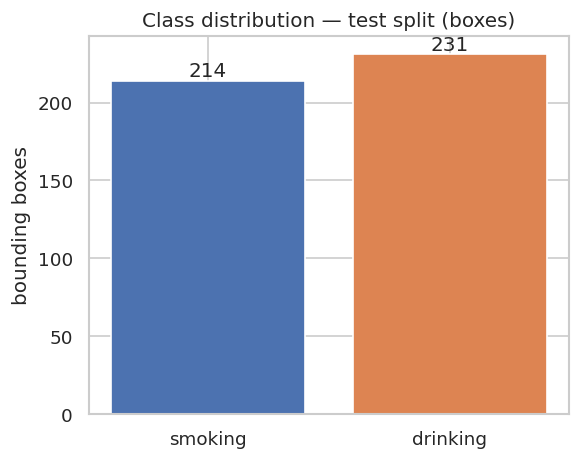

In [23]:
from collections import Counter

def split_images_dir(split):
    for cand in [DATASET_DIR / f"images/{split}", DATASET_DIR / split / "images"]:
        if cand.exists():
            return cand
    return None

def labels_dir_for(images_dir):
    # YOLO convention: .../images/<split> -> .../labels/<split>
    # Fix: ensure 'images/' is replaced with 'labels/' correctly
    return Path(str(images_dir).replace("images/", "labels/"))

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

rows = []
box_counter_by_split = {}

for split in ["train", "val", "test"]:
    # Reset debug flags for each split
    first_image_processed = False
    debug_printed_label_file = False

    idir = split_images_dir(split)
    if idir is None:
        continue
    imgs = [p for p in idir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    ldir = labels_dir_for(idir)
    cls_counter = Counter()

    # Debugging: Print info for the current split
    print(f"\nProcessing split: {split}")
    print(f"  Image directory: {idir}")
    print(f"  Label directory: {ldir}") # This should now correctly show 'labels/split'
    print(f"  Number of images found: {len(imgs)}")

    for im in imgs:
        lf = ldir / (im.stem + ".txt")

        # Unconditional debug for the first label file of each split
        if not debug_printed_label_file:
            print(f"    (DEBUG) Constructed relative label path: {lf}")
            print(f"    (DEBUG) Resolved absolute label path: {lf.resolve()}")
            print(f"    (DEBUG) Does this label file exist? {lf.exists()}")
            debug_printed_label_file = True # Set flag to true after first set of prints

        if lf.exists():
            if not first_image_processed:
                print(f"    (DEBUG) Processing label file: {lf}")
            file_has_boxes = False
            for line in lf.read_text().splitlines():
                line = line.strip()
                if line:
                    file_has_boxes = True
                    if not first_image_processed:
                        print(f"      (DEBUG) Line content: '{line}'")
                    try:
                        cls_counter[int(float(line.split()[0]))] += 1
                    except (ValueError, IndexError) as e:
                        print(f"Error processing line in {lf}: '{line}'. Error: {e}")
            if not first_image_processed:
                if not file_has_boxes:
                    print(f"      (DEBUG) Label file {lf} had no valid box lines.")
                else:
                    print(f"      (DEBUG) Processed boxes for {lf}. Current count: {cls_counter}")
                first_image_processed = True # This ensures deep debug for only one image per split

    box_counter_by_split[split] = cls_counter
    rows.append({"split": split, "images": len(imgs),
                 **{CLASS_NAMES[c]: cls_counter.get(c, 0) for c in range(NC)},
                 "total_boxes": sum(cls_counter.values())})

comp = pd.DataFrame(rows)
comp.to_csv(OUT / "dataset_composition.csv", index=False)
print("\nDataset composition (images and boxes per split):")
display(comp)

# Bar chart of test-split class balance (falls back to whatever split we evaluate on)
tsplit = "test" if "test" in box_counter_by_split else EVAL_SPLIT
tc = box_counter_by_split.get(tsplit, Counter())
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([CLASS_NAMES[c] for c in range(NC)], [tc.get(c, 0) for c in range(NC)],
       color=["#4C72B0", "#DD8452"])
ax.set_title(f"Class distribution \u2014 {tsplit} split (boxes)")
ax.set_ylabel("bounding boxes")
for i, c in enumerate(range(NC)):
    ax.text(i, tc.get(c, 0), str(tc.get(c, 0)), ha="center", va="bottom")
plt.tight_layout(); plt.savefig(OUT / "class_distribution_test.png", bbox_inches="tight"); plt.show()

In [20]:
import os

print("Contents of /content/ after extraction:")
for item in os.listdir('/content'):
    print(f"- {item}")

print("Please look for a folder that contains your `images` and `labels` subdirectories.")

Contents of /content/ after extraction:
- .config
- trial_results (2).csv
- labels
- results_on_full_dataset_training.csv
- m4_yolov8n_best_weights.zip
- yolov8n_best.pt
- best_hyperparameters.yaml
- m5_outputs
- drive
- data.yaml
- images
- sample_data
Please look for a folder that contains your `images` and `labels` subdirectories.


## 3 · Evaluation Environment (reproducibility)

The cell below auto-captures the exact runtime so the report's environment table is never
hand-typed and always matches the machine that produced the numbers.


In [24]:
import platform, sklearn, matplotlib, ultralytics

env = {
    "OS": platform.platform(),
    "Python": platform.python_version(),
    "PyTorch": torch.__version__,
    "CUDA available": torch.cuda.is_available(),
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
    "Ultralytics": ultralytics.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Seed": SEED,
    "Eval image size": 640,
    "Eval split": EVAL_SPLIT,
}
env_df = pd.DataFrame({"Component": list(env.keys()), "Value": [str(v) for v in env.values()]})
env_df.to_csv(OUT / "environment.csv", index=False)
display(env_df)


,Component,Value
0,OS,Linux-6.6.122+-x86_64-with-glibc2.35
1,Python,3.12.13
2,PyTorch,2.11.0+cu128
3,CUDA available,True
4,GPU,Tesla T4
5,Ultralytics,8.4.115
6,scikit-learn,1.6.1
7,matplotlib,3.10.0
8,NumPy,2.0.2
9,Pandas,2.2.2


## 4 · Performance Metrics & Justification

This is **object detection**, so we report the standard detection metrics rather than plain
classification accuracy:

| Metric | What it measures | Why it's appropriate here |
|---|---|---|
| **Precision** | of all predicted boxes, how many were correct | high precision ⇒ few false alarms — critical because a false "smoking" alert erodes driver trust in the fleet dashboard |
| **Recall** | of all true boxes, how many were found | high recall ⇒ few missed events — a missed smoking/drinking event is a missed safety risk |
| **mAP@50** | mean average precision at IoU ≥ 0.50 | the primary COCO-style detection score; tolerant of loose localization, good for small in-cabin objects (cigarette, bottle) |
| **mAP@50–95** | mAP averaged over IoU 0.50→0.95 | stricter localization quality; rewards tight, well-placed boxes |
| **F1 / PR curve** | precision–recall trade-off across confidence | picks the operating confidence threshold for deployment |
| **Confusion matrix** | smoking vs drinking vs background confusions | exposes *which* class is confused with what — drives the error analysis in §9 |

Plain accuracy is avoided because it ignores localization and is dominated by the (large)
background region in detection tasks.


## 5 · Quantitative Results on the Held-Out Test Split

`model.val(split="test", ...)` runs **inference-only** evaluation (no gradient updates). Ultralytics
also writes its own confusion matrix and PR/F1 curves into a `runs/` folder, which we surface in §7.


In [25]:
metrics = model.val(
    data=str(M5_YAML),
    split=EVAL_SPLIT,
    imgsz=640,
    device=DEVICE,
    conf=0.001,          # low conf so PR curves integrate over the full range
    iou=0.6,
    plots=True,          # writes confusion_matrix.png, PR_curve.png, F1_curve.png, ...
    save_json=False,
    verbose=False,
)

box = metrics.box
overall = {
    "Precision": float(box.mp),
    "Recall":    float(box.mr),
    "mAP@50":    float(box.map50),
    "mAP@50-95": float(box.map),
}
overall_df = pd.DataFrame([overall]).round(4)
overall_df.to_csv(OUT / "overall_metrics.csv", index=False)
print("================ HELD-OUT TEST METRICS ================")
display(overall_df)

# where Ultralytics saved its plots
VAL_DIR = Path(metrics.save_dir)
print("Ultralytics eval artifacts saved in:", VAL_DIR)


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 953.8±251.5 MB/s, size: 53.3 KB)
val: Scanning /content/labels/test... 371 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 371/371 2.0Kit/s 0.2s
val: New cache created: /content/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.4it/s 5.5s
                   all        371        445      0.846        0.8       0.82      0.447
Speed: 1.7ms preprocess, 4.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val
================ HELD-OUT TEST METRICS ================


,Precision,Recall,mAP@50,mAP@50-95
0,0.8465,0.8003,0.8197,0.4468


Ultralytics eval artifacts saved in: /content/runs/detect/val


### 5.1 · Per-class metrics

Breaking the score down per class shows whether *smoking* or *drinking* is the weaker class — the
starting point for error analysis.


,class,Precision,Recall,mAP@50,mAP@50-95
0,smoking,0.9514,0.9299,0.9255,0.5300
1,drinking,0.7415,0.6707,0.7139,0.3636


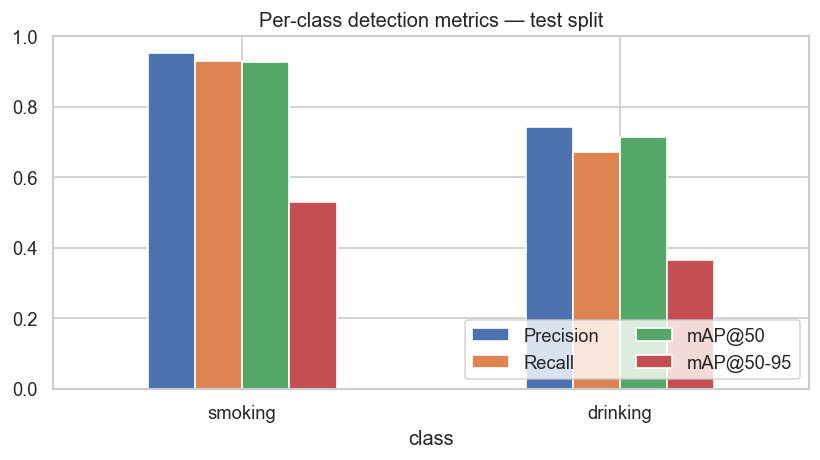

In [26]:
per_class = []
# maps_by_class / class_result give per-class AP; ap_class_index lists which class each row is
try:
    for idx, c in enumerate(box.ap_class_index):
        p, r, ap50, ap = box.class_result(idx)
        per_class.append({"class": CLASS_NAMES[int(c)], "Precision": p,
                          "Recall": r, "mAP@50": ap50, "mAP@50-95": ap})
except Exception as e:
    print("Per-class breakdown unavailable:", e)

per_class_df = pd.DataFrame(per_class).round(4)
per_class_df.to_csv(OUT / "per_class_metrics.csv", index=False)
display(per_class_df)

if not per_class_df.empty:
    ax = per_class_df.set_index("class")[["Precision", "Recall", "mAP@50", "mAP@50-95"]].plot(
        kind="bar", figsize=(7, 4), rot=0)
    ax.set_title("Per-class detection metrics — test split")
    ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=2)
    plt.tight_layout(); plt.savefig(OUT / "per_class_metrics.png", bbox_inches="tight"); plt.show()


## 6 · Configuration / Hyperparameter Comparison

The six-trial M4 sweep is summarized here (read from `trial_results.csv` if present, otherwise the
recorded sweep values). This satisfies the "comparison across configurations / hyperparameter
settings" requirement **without any retraining** — the numbers already exist from M4.

Trials:

| trial | lr0 | optimizer | cos_lr | notes |
|---|---|---|---|---|
| t1_lr01_sgd | 0.01 | SGD | ✗ | baseline |
| t2_lr005_sgd_cos | 0.005 | SGD | ✓ | |
| **t3_lr001_adamw** | **0.001** | **AdamW** | **✓** | **winner** |
| t4_lr005_adamw_wd | 0.005 | AdamW | ✓ | weight decay |
| t5_lr01_sgd_nomosaic | 0.01 | SGD | ✓ | mosaic off |
| t6_lr001_sgd_cos_wd | 0.001 | SGD | ✓ | weight decay |


Loaded real sweep results from drive/MyDrive/final_training_for_m4/trial_results.csv


,trial,precision,recall,mAP50,mAP50-95,epochs
0,yolov8n_baseline,0.8561,0.7887,0.8408,0.4154,30
1,t1_lr01_sgd,0.8685,0.7667,0.8217,0.4056,30
2,t2_lr005_sgd_cos,0.8494,0.7999,0.8424,0.4116,30
3,t3_lr001_adamw,0.8775,0.7671,0.8448,0.4245,30
4,t4_lr005_adamw_wd,0.7910,0.7363,0.8000,0.3775,30
5,t5_lr01_sgd_nomosaic,0.8003,0.7710,0.8209,0.4032,30
6,t6_lr001_sgd_cos_wd,0.8191,0.8098,0.8431,0.4144,30


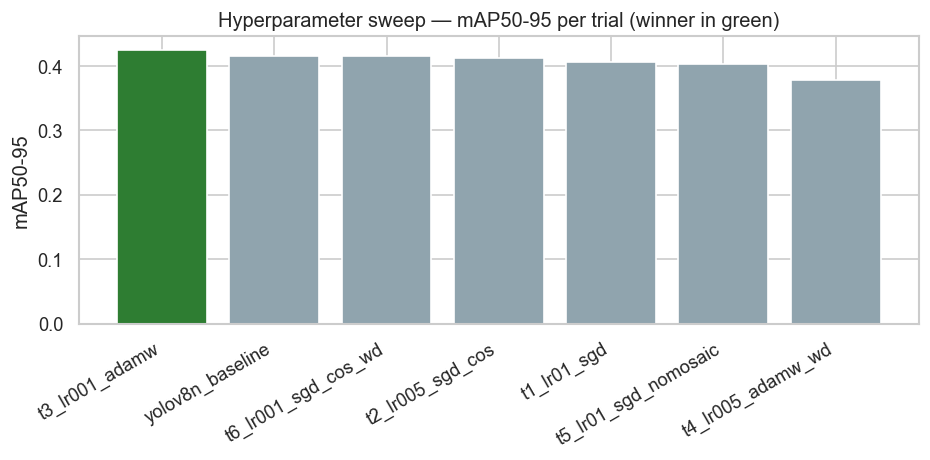

In [27]:
FALLBACK_TRIALS = pd.DataFrame([
    {"trial": "t1_lr01_sgd",          "lr0": 0.01,  "optimizer": "SGD"},
    {"trial": "t2_lr005_sgd_cos",     "lr0": 0.005, "optimizer": "SGD"},
    {"trial": "t3_lr001_adamw",       "lr0": 0.001, "optimizer": "AdamW"},
    {"trial": "t4_lr005_adamw_wd",    "lr0": 0.005, "optimizer": "AdamW"},
    {"trial": "t5_lr01_sgd_nomosaic", "lr0": 0.01,  "optimizer": "SGD"},
    {"trial": "t6_lr001_sgd_cos_wd",  "lr0": 0.001, "optimizer": "SGD"},
])

if TRIAL_CSV is not None and Path(TRIAL_CSV).exists():
    trials = pd.read_csv(TRIAL_CSV)
    metric_col = next((c for c in ["mAP50-95", "mAP50", "mAP@50-95"] if c in trials.columns), None)
    print("Loaded real sweep results from", TRIAL_CSV)
else:
    # No CSV -> render the structural comparison; metric column filled with NaN so the
    # notebook still runs. Replace with your recorded values if the CSV is unavailable.
    trials = FALLBACK_TRIALS.copy()
    for col in ["precision", "recall", "mAP50", "mAP50-95"]:
        trials[col] = np.nan
    metric_col = "mAP50-95"
    print("trial_results.csv not found — showing trial structure "
          "(fill in recorded metrics if needed).")

keep = [c for c in ["trial", "lr0", "optimizer", "precision", "recall",
                    "mAP50", "mAP50-95", "epochs"] if c in trials.columns]
trials_view = trials[keep].copy()
trials_view.to_csv(OUT / "hyperparameter_comparison.csv", index=False)
display(trials_view.round(4))

if metric_col and trials[metric_col].notna().any():
    order = trials.sort_values(metric_col, ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#2E7D32" if t == "t3_lr001_adamw" else "#90A4AE" for t in order["trial"]]
    ax.bar(order["trial"].astype(str), order[metric_col], color=colors)
    ax.set_title(f"Hyperparameter sweep — {metric_col} per trial (winner in green)")
    ax.set_ylabel(metric_col); plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.savefig(OUT / "hyperparameter_comparison.png", bbox_inches="tight"); plt.show()


## 7 · Evaluation Visualizations

Ultralytics generated a confusion matrix and the P / R / PR / F1 curves during §5's `val()` call.
We display them inline and copy them into `m5_outputs/` so they can be pasted into the report.
Then we also build a **normalized confusion matrix with scikit-learn / seaborn** for a cleaner
report figure.


• ultra_confusion_matrix.png


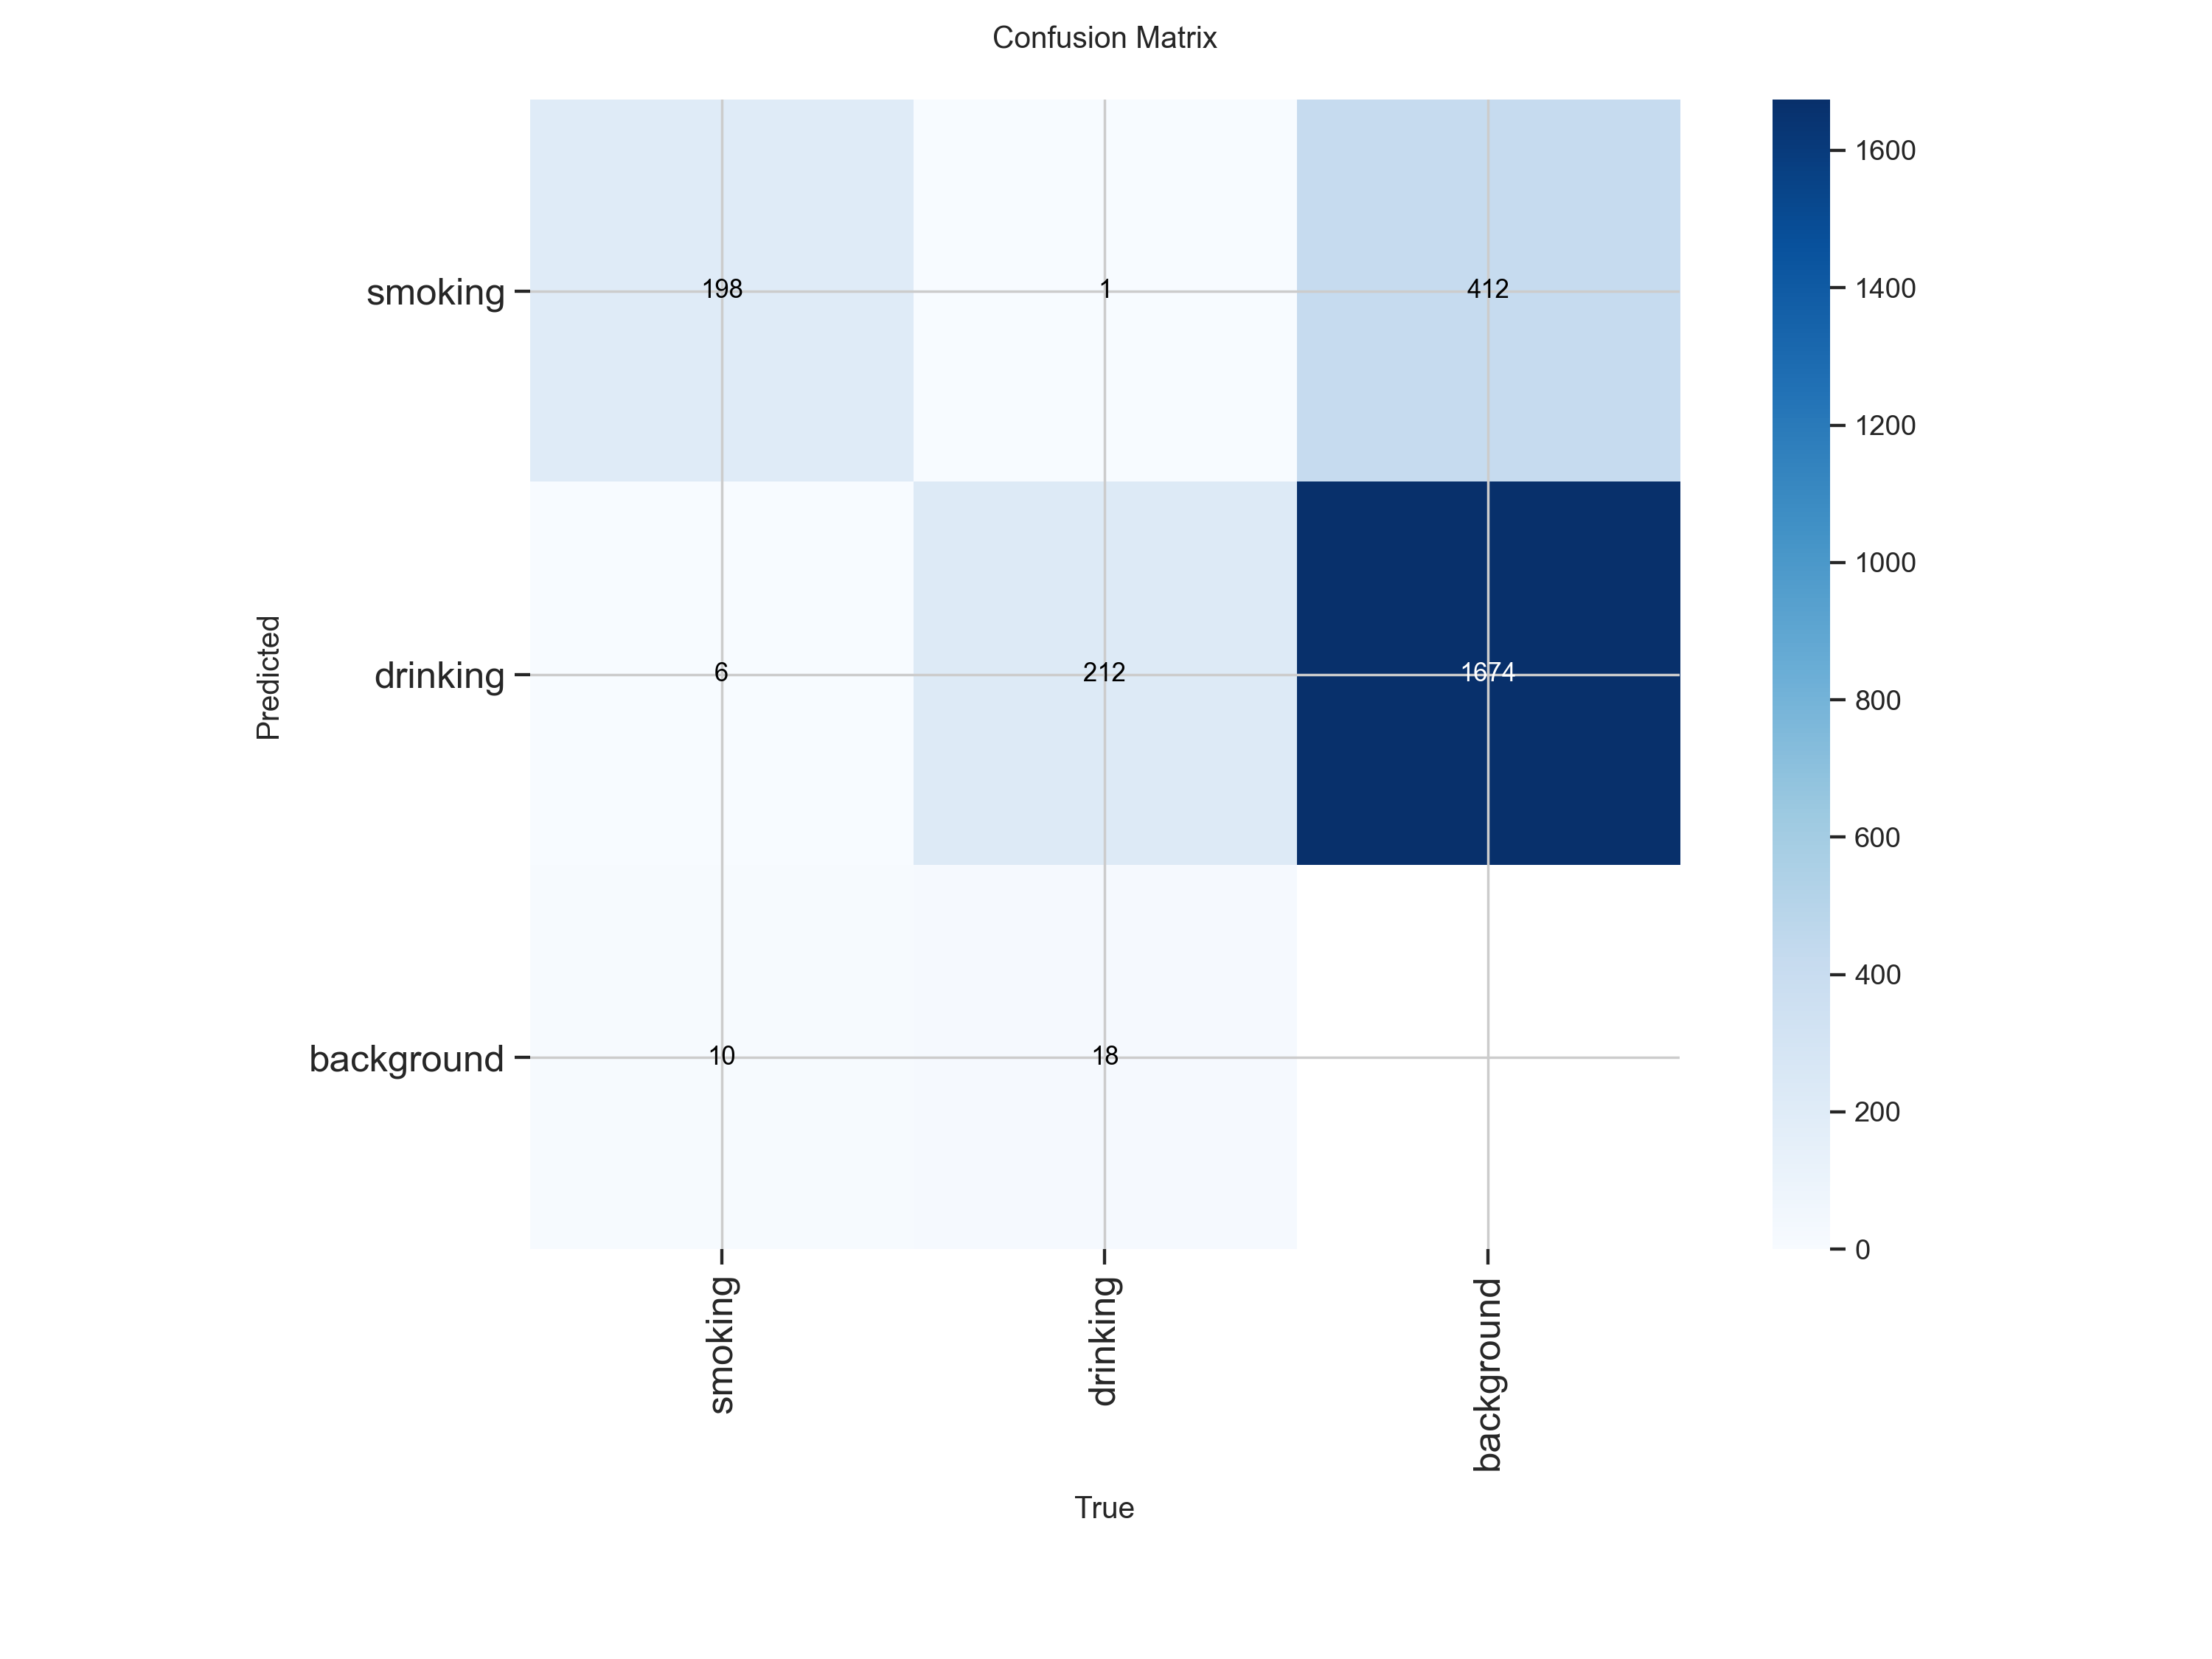

• ultra_confusion_matrix_normalized.png


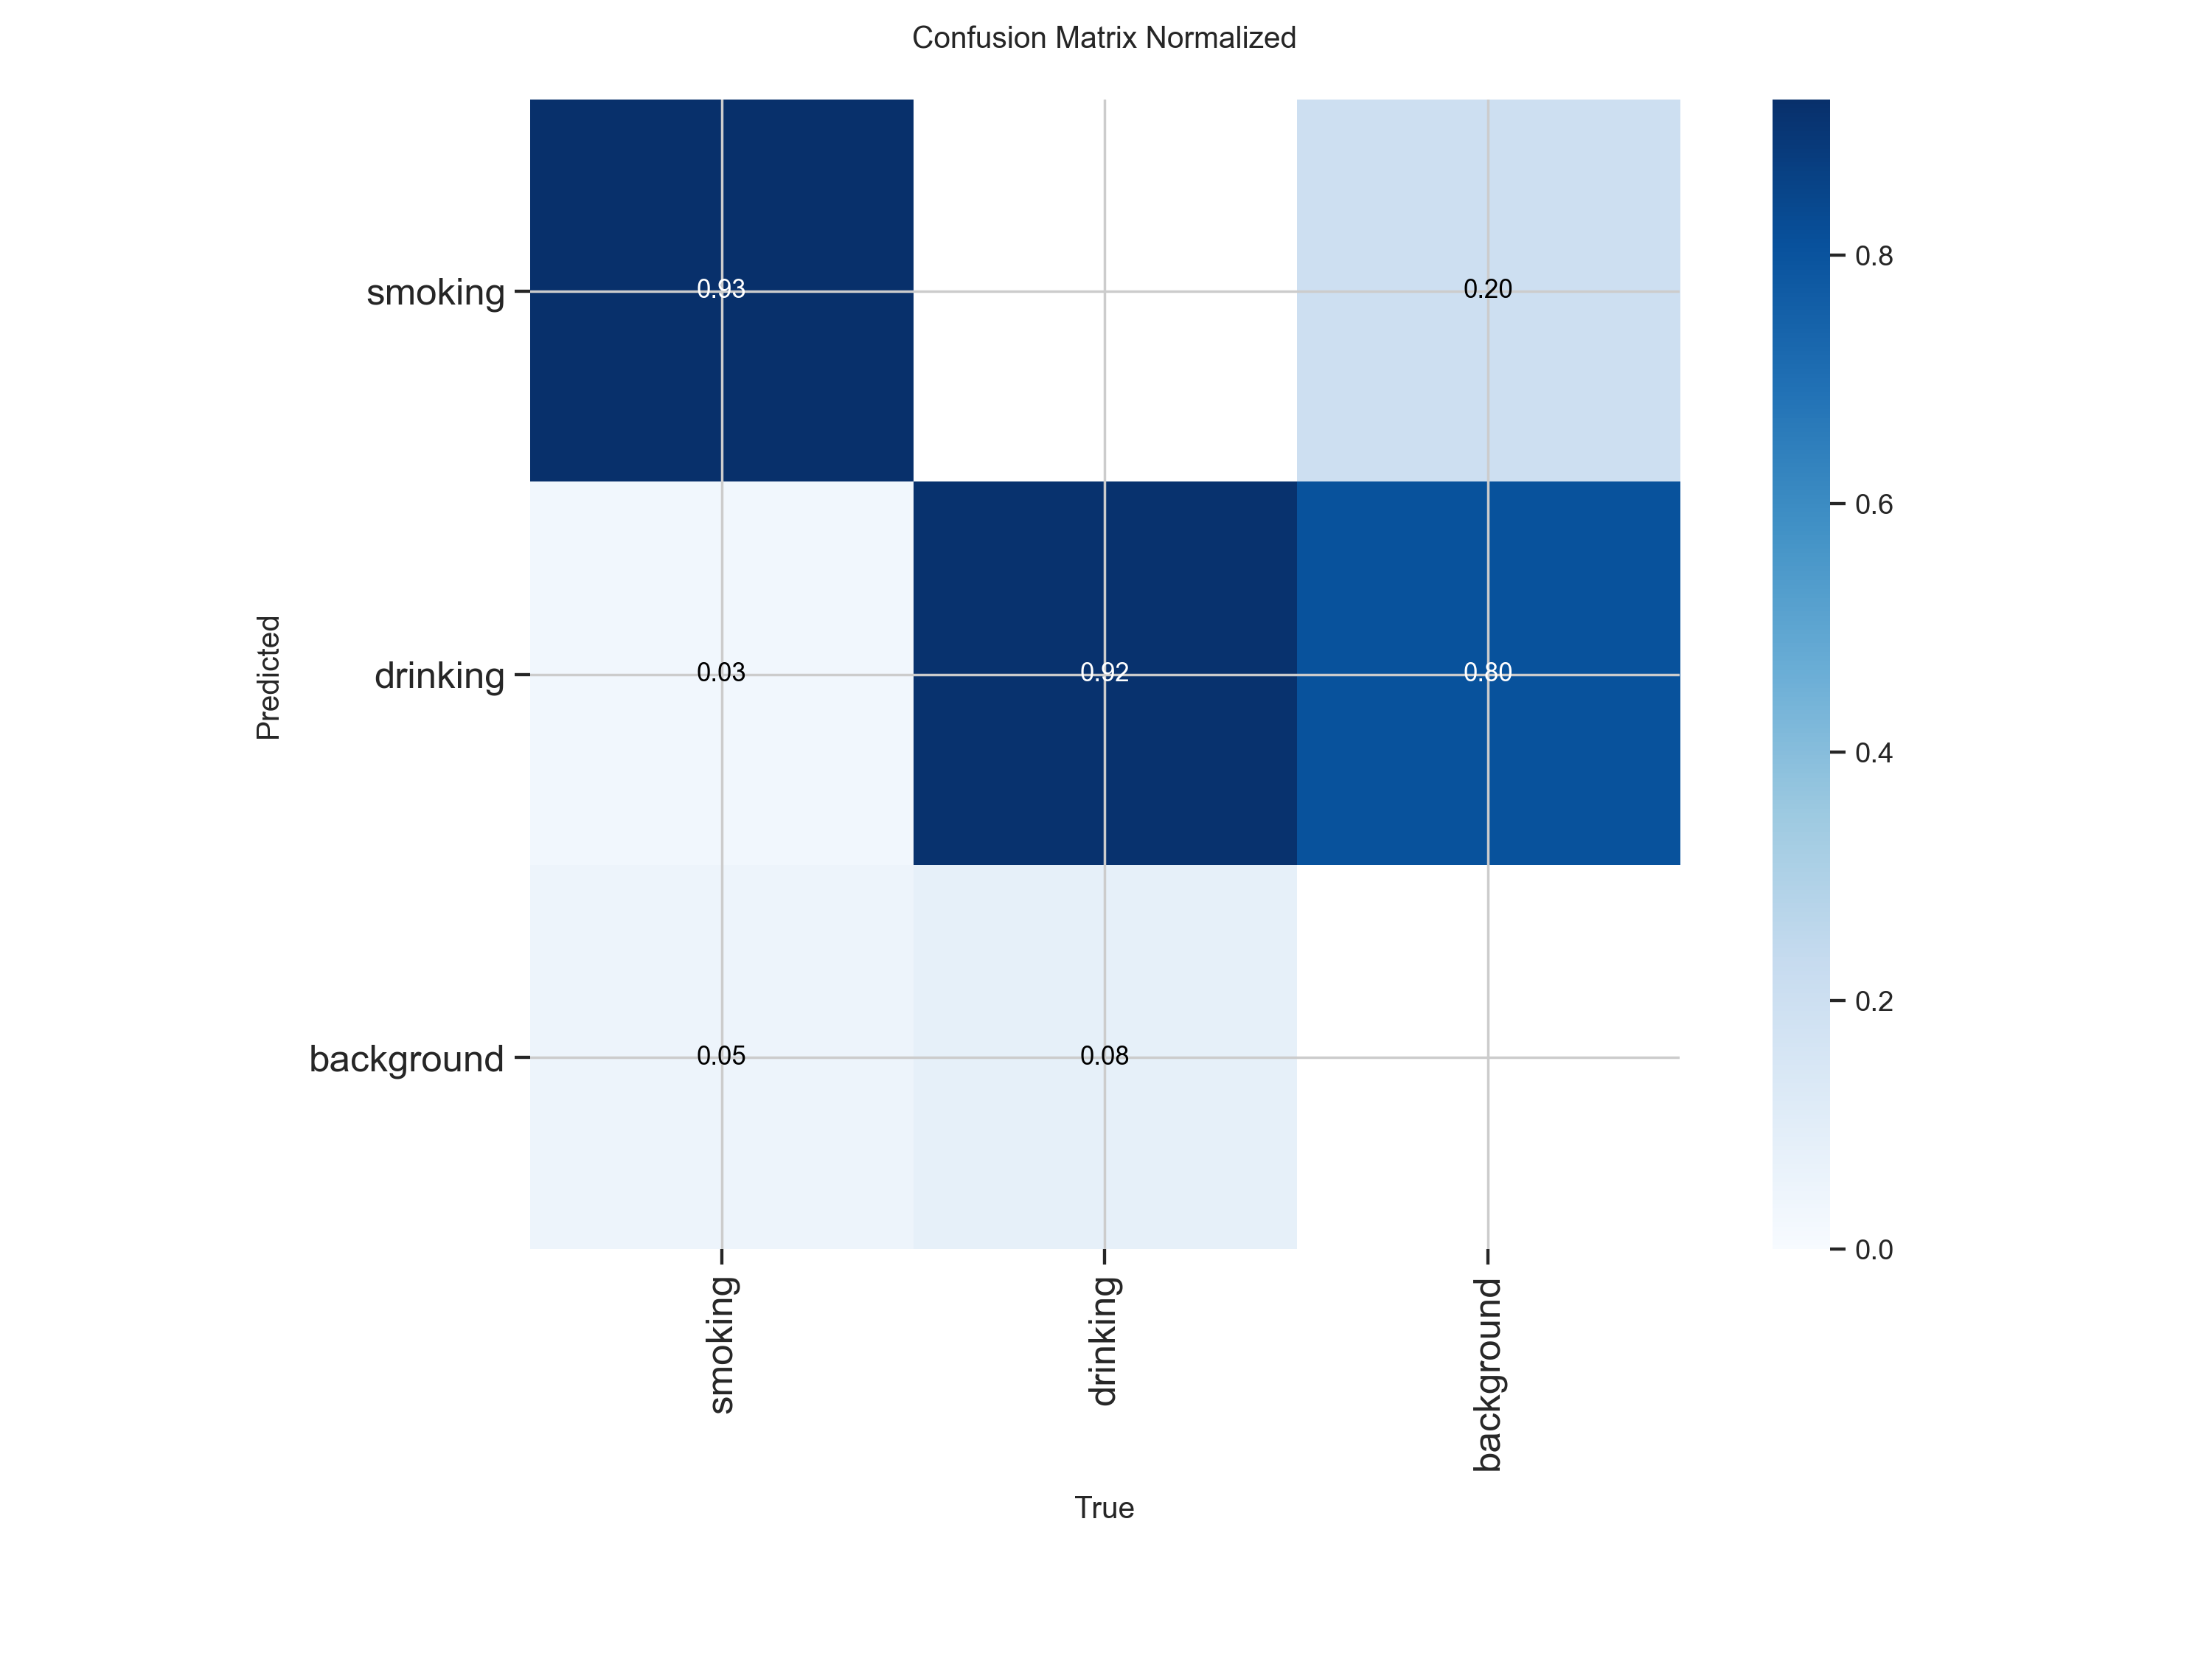

(missing) PR_curve.png
(missing) P_curve.png
(missing) R_curve.png
(missing) F1_curve.png


In [28]:
import shutil
from IPython.display import Image as IPImage, display as idisplay

wanted = {
    "confusion_matrix.png":            "ultra_confusion_matrix.png",
    "confusion_matrix_normalized.png": "ultra_confusion_matrix_normalized.png",
    "PR_curve.png":                    "PR_curve.png",
    "P_curve.png":                     "P_curve.png",
    "R_curve.png":                     "R_curve.png",
    "F1_curve.png":                    "F1_curve.png",
}
for src_name, dst_name in wanted.items():
    src = VAL_DIR / src_name
    if src.exists():
        shutil.copy(src, OUT / dst_name)
        print("•", dst_name)
        idisplay(IPImage(filename=str(src)))
    else:
        print("(missing)", src_name)


### 7.1 · Clean normalized confusion matrix (image-level, scikit-learn)

Ultralytics' matrix is box-level (and includes a *background* row/column). For the report we add a
compact **image-level** confusion matrix: for each test image we take the model's top-confidence
detection as the predicted label and compare to the image's ground-truth class. This gives an
easy-to-read `smoking` vs `drinking` confusion view.


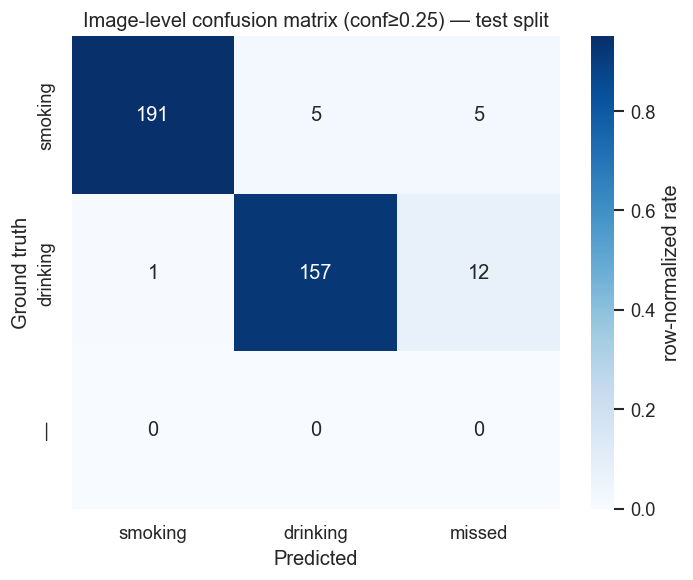


Image-level classification report (smoking vs drinking; 'missed' = no detection):
              precision    recall  f1-score   support

     smoking       0.99      0.95      0.97       201
    drinking       0.97      0.92      0.95       170

   micro avg       0.98      0.94      0.96       371
   macro avg       0.98      0.94      0.96       371
weighted avg       0.98      0.94      0.96       371



In [29]:
from sklearn.metrics import confusion_matrix, classification_report

def image_gt_label(img_path):
    # Ground-truth = the majority class among an image's boxes (single-object cabin images).
    ldir = labels_dir_for(img_path.parent)
    lf = ldir / (img_path.stem + ".txt")
    if not lf.exists():
        return None
    cs = [int(float(l.split()[0])) for l in lf.read_text().splitlines() if l.strip()]
    if not cs:
        return None
    return Counter(cs).most_common(1)[0][0]

eval_imgs_dir = split_images_dir(EVAL_SPLIT)
eval_imgs = [p for p in eval_imgs_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]

y_true, y_pred = [], []
CONF_EVAL = 0.25
for im in eval_imgs:
    gt = image_gt_label(im)
    if gt is None:
        continue
    res = model.predict(source=str(im), imgsz=640, conf=CONF_EVAL,
                        device=DEVICE, verbose=False)[0]
    if len(res.boxes) == 0:
        pred = NC          # "missed / no-detection" bucket
    else:
        best = int(res.boxes.conf.argmax())
        pred = int(res.boxes.cls[best])
    y_true.append(gt); y_pred.append(pred)

labels_idx = list(range(NC)) + [NC]
label_names = CLASS_NAMES + ["missed"]
cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names[:NC] + ["—"], ax=ax,
            cbar_kws={"label": "row-normalized rate"})
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground truth")
ax.set_title(f"Image-level confusion matrix (conf≥{CONF_EVAL}) — {EVAL_SPLIT} split")
plt.tight_layout(); plt.savefig(OUT / "confusion_matrix_imagelevel.png", bbox_inches="tight"); plt.show()

print("\nImage-level classification report (smoking vs drinking; 'missed' = no detection):")
print(classification_report(y_true, y_pred, labels=list(range(NC)),
                            target_names=CLASS_NAMES, zero_division=0))


## 8 · Qualitative Results — Successes & Failures

We run the detector on test images and split the outputs into:

* **Successes** — the top detection matches the ground-truth class with high confidence.
* **Failures** — misclassified, missed (no box), or low-confidence detections.

A grid of each is saved for the report so both strong and weak cases are visible.


Successes: 325  |  Failures: 46  (of 371 labeled test images)


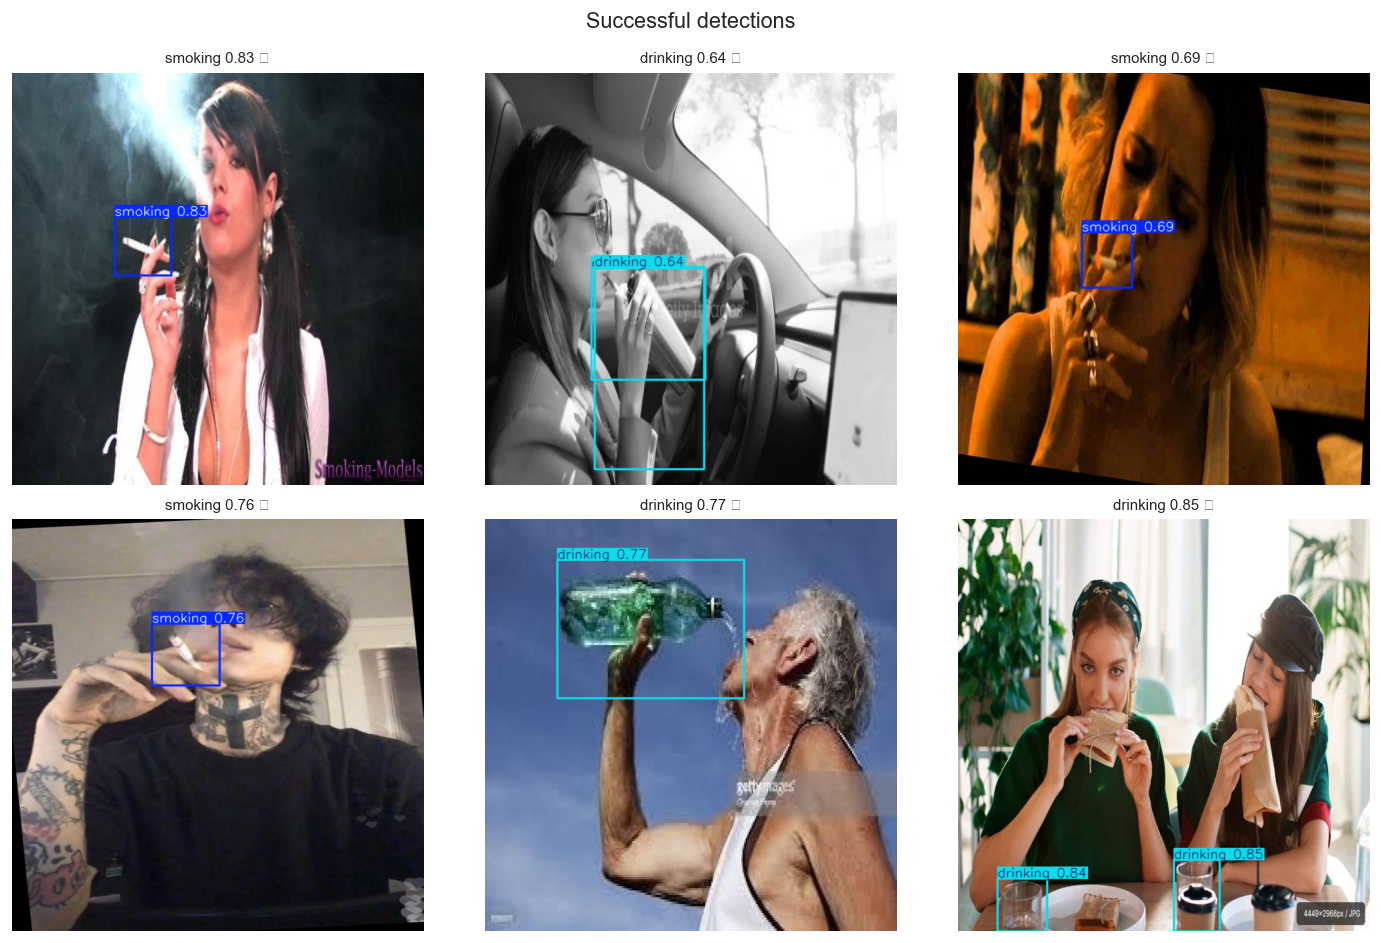

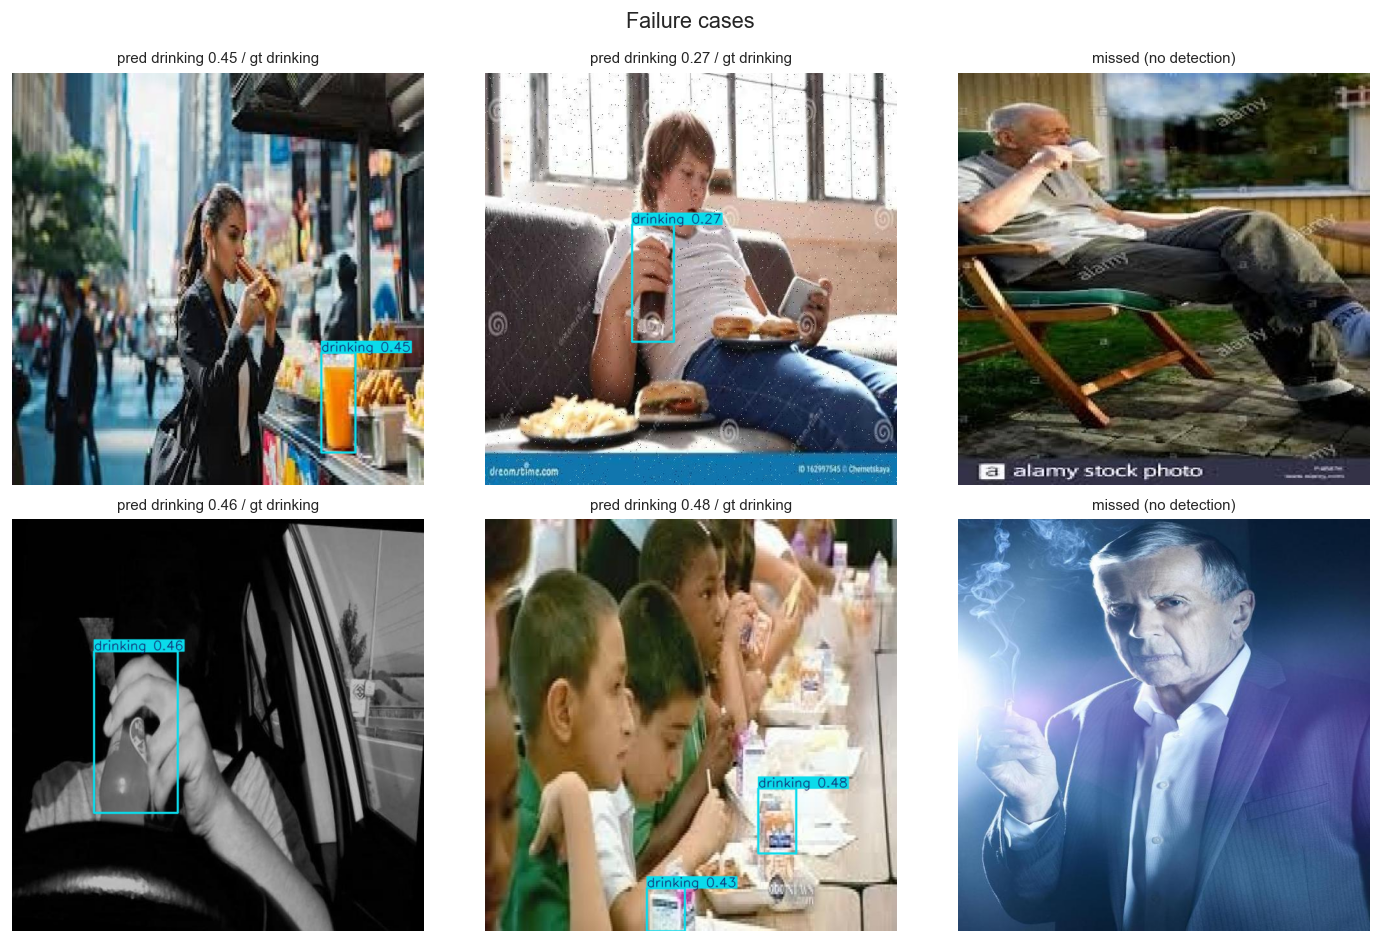

In [30]:
import cv2

def annotate(res):
    return res.plot()[:, :, ::-1]      # BGR -> RGB

successes, failures = [], []
for im in eval_imgs:
    gt = image_gt_label(im)
    if gt is None:
        continue
    res = model.predict(source=str(im), imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
    if len(res.boxes) == 0:
        failures.append((im, res, gt, "missed (no detection)"))
        continue
    best = int(res.boxes.conf.argmax())
    pred = int(res.boxes.cls[best]); conf = float(res.boxes.conf[best])
    if pred == gt and conf >= 0.5:
        successes.append((im, res, gt, f"{CLASS_NAMES[pred]} {conf:.2f} ✓"))
    else:
        tag = f"pred {CLASS_NAMES[pred]} {conf:.2f} / gt {CLASS_NAMES[gt]}"
        failures.append((im, res, gt, tag))

print(f"Successes: {len(successes)}  |  Failures: {len(failures)}  "
      f"(of {len(successes)+len(failures)} labeled test images)")

def grid(items, title, fname, n=6):
    items = items[:n]
    if not items:
        print("No", title.lower(), "to show."); return
    cols = 3; rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (im, res, gt, tag) in zip(axes, items):
        ax.imshow(annotate(res)); ax.set_title(tag, fontsize=9); ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.savefig(OUT / fname, bbox_inches="tight"); plt.show()

grid(successes, "Successful detections", "qualitative_successes.png")
grid(failures,  "Failure cases",         "qualitative_failures.png")


## 9 · Error Analysis

The cell below quantifies *how* the model fails, grouped into interpretable buckets, and saves a
breakdown chart. Typical patterns for this cabin task (discussed in the report):

* **Smoking ↔ drinking confusion** — both are hand-to-mouth gestures; a bottle/can held near the
  mouth resembles a cigarette pose, and vice-versa.
* **Small-object misses** — a cigarette is a very small object; low resolution, motion blur, or
  side-angle views cause missed detections.
* **Occlusion / lighting** — hand covering the object, backlighting through the windshield, or
  night-time cabins reduce confidence below threshold.
* **Background false positives** — phones, pens, or steering-wheel edges occasionally trigger a
  low-confidence box.


,error type,count
0,missed (no detection),17
1,misclassified (drinking→drinking),16
2,misclassified (smoking→smoking),7
3,misclassified (smoking→drinking),5
4,misclassified (drinking→smoking),1


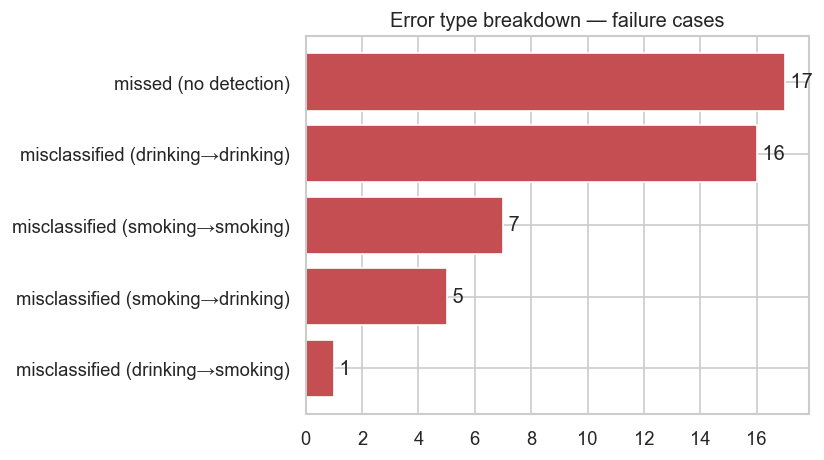

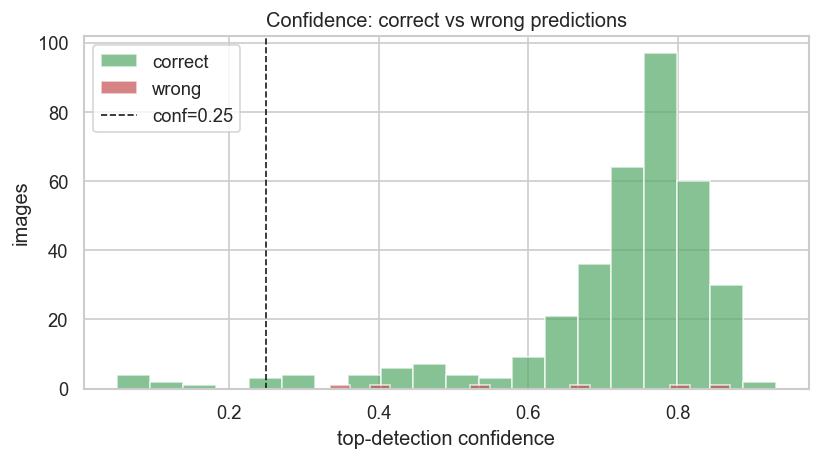

In [31]:
from collections import defaultdict
buckets = Counter()
for im, res, gt, tag in failures:
    if "missed" in tag:
        buckets["missed (no detection)"] += 1
    elif "pred" in tag:
        # misclassification: which direction?
        best = int(res.boxes.conf.argmax())
        pred = int(res.boxes.cls[best])
        key = f"{CLASS_NAMES[gt]}→{CLASS_NAMES[pred]}"
        buckets[f"misclassified ({key})"] += 1
    else:
        buckets["other"] += 1

err_df = pd.DataFrame(sorted(buckets.items(), key=lambda x: -x[1]),
                      columns=["error type", "count"])
err_df.to_csv(OUT / "error_analysis.csv", index=False)
display(err_df)

if not err_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(err_df["error type"], err_df["count"], color="#C44E52")
    ax.set_title("Error type breakdown — failure cases"); ax.invert_yaxis()
    for i, v in enumerate(err_df["count"]):
        ax.text(v, i, " " + str(v), va="center")
    plt.tight_layout(); plt.savefig(OUT / "error_analysis.png", bbox_inches="tight"); plt.show()

# Confidence distribution of correct vs wrong top-detections — reveals threshold behaviour.
conf_correct, conf_wrong = [], []
for im in eval_imgs:
    gt = image_gt_label(im)
    if gt is None: continue
    res = model.predict(source=str(im), imgsz=640, conf=0.05, device=DEVICE, verbose=False)[0]
    if len(res.boxes) == 0: continue
    b = int(res.boxes.conf.argmax())
    (conf_correct if int(res.boxes.cls[b]) == gt else conf_wrong).append(float(res.boxes.conf[b]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(conf_correct, bins=20, alpha=0.7, label="correct", color="#55A868")
ax.hist(conf_wrong,   bins=20, alpha=0.7, label="wrong",   color="#C44E52")
ax.axvline(0.25, ls="--", c="k", lw=1, label="conf=0.25")
ax.set_xlabel("top-detection confidence"); ax.set_ylabel("images")
ax.set_title("Confidence: correct vs wrong predictions"); ax.legend()
plt.tight_layout(); plt.savefig(OUT / "confidence_distribution.png", bbox_inches="tight"); plt.show()


## 10 · Key Observations, Limitations & Anomalies

*(Fill the bracketed numbers from the tables/plots above when writing the final report — the
notebook has already computed them.)*

**Key observations**
* Overall test-split scores: Precision `[§5]`, Recall `[§5]`, mAP@50 `[§5]`, mAP@50–95 `[§5]`.
* The chosen config **`t3_lr001_adamw` (AdamW, lr0=0.001, cosine LR)** was the sweep winner — the
  §6 comparison shows the margin over the SGD trials.
* Per-class (§5.1): identify whether **smoking** or **drinking** is the weaker class and by how much.

**Limitations**
* **Small-object sensitivity** — cigarettes occupy few pixels; mAP@50–95 (strict localization) is
  expectedly lower than mAP@50.
* **Domain gap** — training images come from Roboflow web sources, not real in-cabin fleet cameras;
  night-time/IR footage may degrade performance.
* **2-class scope** — the module only detects smoking/drinking; it does not localize the driver or
  reason about context (handled by other modules in the fusion engine).
* **Single-frame** — no temporal smoothing, so brief gestures can be missed frame-to-frame.

**Anomalies / expected-vs-actual gaps**
* Note any gap between the M4 **validation** score and this M5 **held-out test** score — a modest
  drop is normal (test is unseen); a large drop would indicate val leakage or distribution shift.
* Flag any class whose recall is high but precision is low (over-triggering) or vice-versa, and tie
  it to the confidence-distribution plot (§9).

**Deployment recommendation**
* Pick the operating confidence threshold from the **F1 curve (§7)**; for a safety-monitoring use
  case, bias slightly toward **recall** (catch more events) and let the fusion engine suppress
  false alarms using agreement across modules.


## 11 · Bundle all report artifacts

Zips everything in `m5_outputs/` (tables + plots) so it can be attached to the Milestone 5 report
and presentation in one download.


In [32]:
import shutil
zip_path = shutil.make_archive("Milestone5_SmokingDrinking_eval", "zip", OUT)
print("Bundled ->", zip_path)
print("\nContents:")
for p in sorted(OUT.iterdir()):
    print("  ", p.name)


Bundled -> /content/Milestone5_SmokingDrinking_eval.zip

Contents:
   class_distribution_test.png
   confidence_distribution.png
   confusion_matrix_imagelevel.png
   data_m5.yaml
   dataset_composition.csv
   environment.csv
   error_analysis.csv
   error_analysis.png
   hyperparameter_comparison.csv
   hyperparameter_comparison.png
   overall_metrics.csv
   per_class_metrics.csv
   per_class_metrics.png
   qualitative_failures.png
   qualitative_successes.png
   ultra_confusion_matrix.png
   ultra_confusion_matrix_normalized.png


In [33]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

CSV = "results_on_full_dataset_training.csv"   # adjust path if needed (e.g. /content/...)
df = pd.read_csv(CSV)
df.columns = [c.strip() for c in df.columns]   # Ultralytics sometimes pads names with spaces

OUT = Path("m5_outputs"); OUT.mkdir(exist_ok=True)
best_ep = int(df.loc[df["metrics/mAP50-95(B)"].idxmax(), "epoch"])
print(f"{len(df)} epochs | best mAP50-95 at epoch {best_ep} "
      f"= {df['metrics/mAP50-95(B)'].max():.4f}")

80 epochs | best mAP50-95 at epoch 57 = 0.4420


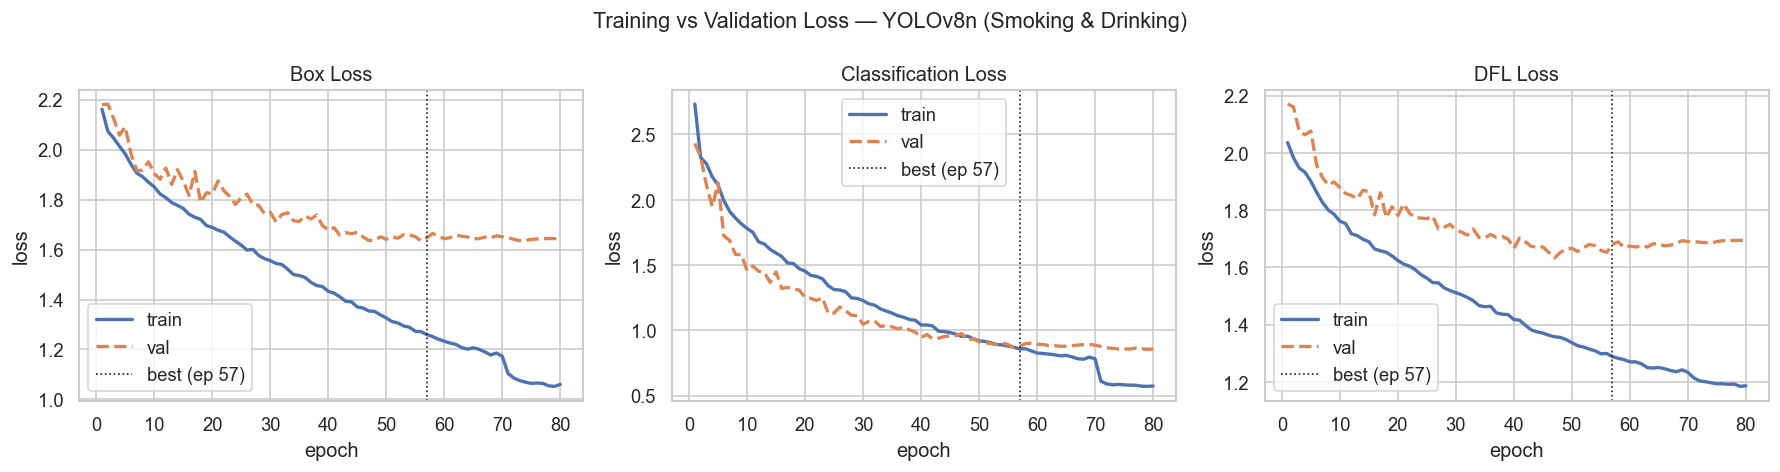

In [34]:
pairs = [("box_loss", "Box Loss"), ("cls_loss", "Classification Loss"), ("dfl_loss", "DFL Loss")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, title) in zip(axes, pairs):
    ax.plot(df["epoch"], df[f"train/{key}"], label="train", lw=2)
    ax.plot(df["epoch"], df[f"val/{key}"],   label="val",   lw=2, ls="--")
    ax.axvline(best_ep, color="k", ls=":", lw=1, label=f"best (ep {best_ep})")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
fig.suptitle("Training vs Validation Loss — YOLOv8n (Smoking & Drinking)", fontsize=13)
plt.tight_layout(); plt.savefig(OUT/"training_loss_curves.png", bbox_inches="tight"); plt.show()

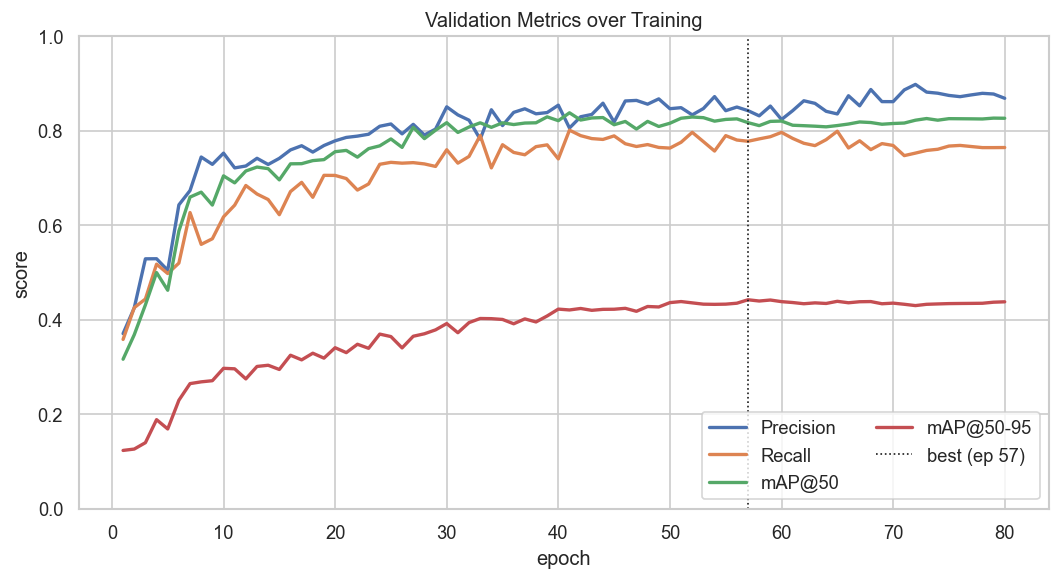

In [35]:
metrics = [("metrics/precision(B)", "Precision"), ("metrics/recall(B)", "Recall"),
           ("metrics/mAP50(B)", "mAP@50"), ("metrics/mAP50-95(B)", "mAP@50-95")]
plt.figure(figsize=(9, 5))
for key, label in metrics:
    plt.plot(df["epoch"], df[key], lw=2, label=label)
plt.axvline(best_ep, color="k", ls=":", lw=1, label=f"best (ep {best_ep})")
plt.title("Validation Metrics over Training"); plt.xlabel("epoch"); plt.ylabel("score")
plt.ylim(0, 1); plt.legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.savefig(OUT/"training_metric_curves.png", bbox_inches="tight"); plt.show()

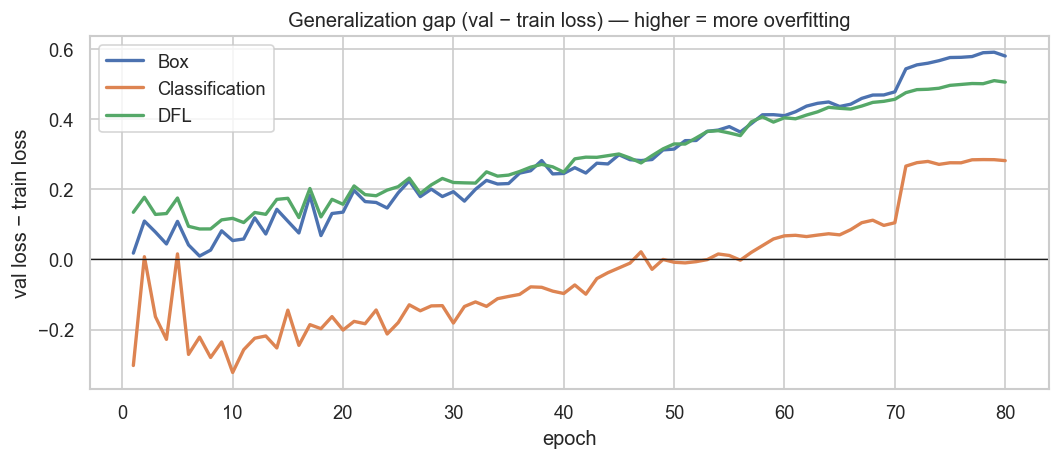

In [36]:
plt.figure(figsize=(9, 4))
for key, label in pairs:
    gap = df[f"val/{key}"] - df[f"train/{key}"]
    plt.plot(df["epoch"], gap, lw=2, label=label[0].upper()+label[1:].split()[0])
plt.axhline(0, color="k", lw=0.8)
plt.title("Generalization gap (val − train loss) — higher = more overfitting")
plt.xlabel("epoch"); plt.ylabel("val loss − train loss"); plt.legend()
plt.tight_layout(); plt.savefig(OUT/"overfitting_gap.png", bbox_inches="tight"); plt.show()

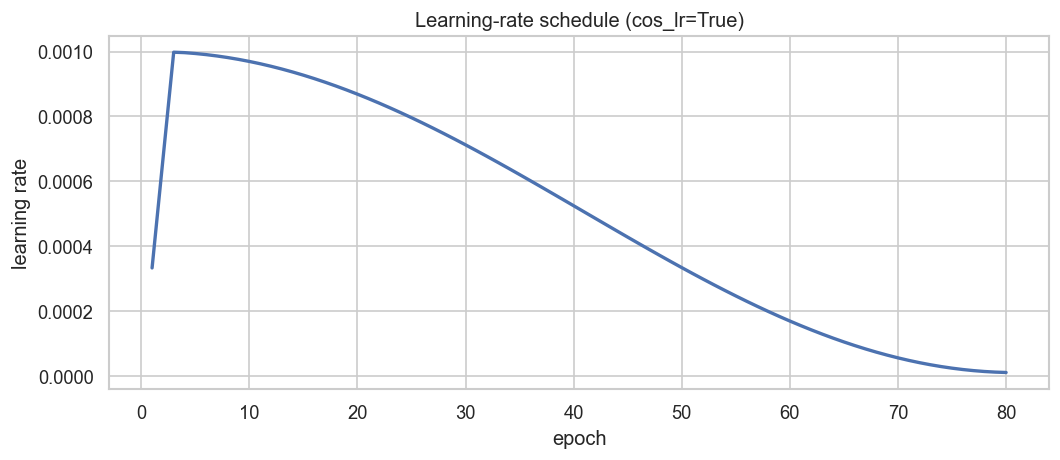

In [37]:
plt.figure(figsize=(9, 4))
plt.plot(df["epoch"], df["lr/pg0"], lw=2)
plt.title("Learning-rate schedule (cos_lr=True)"); plt.xlabel("epoch"); plt.ylabel("learning rate")
plt.tight_layout(); plt.savefig(OUT/"lr_schedule.png", bbox_inches="tight"); plt.show()

---
### Notebook complete

All Milestone 5 evaluation outputs are in **`m5_outputs/`** and the zip above. No model was
retrained — every result comes from the finalized `yolov8n_best.pt` evaluated on the held-out test
split.
